# Versao 10 - Comparacao LSTM Multitarefa Vs Baselines

A `versao10` so cumpre seu papel se a comparacao final for honesta. Este notebook reexecuta as baselines tabulares sobre os artefatos da `versao10` e coloca a nova rede lado a lado com as referencias anteriores.

## Sintese Numerica Da Ultima Execucao

| Modelo | Accuracy | Macro-F1 | Balanced Accuracy |
| --- | ---: | ---: | ---: |
| `LSTM v6` | `0.9433` | `0.9185` | `0.9367` |
| `LSTM v9` | `0.9224` | `0.9268` | `0.9415` |
| `LSTM v10` | `0.9373` | `0.9409` | `0.9572` |
| `RandomForest` | `0.9851` | `0.9811` | `0.9744` |
| `XGBoost` | `0.9791` | `0.9775` | `0.9714` |

Leitura orientada pelos numeros:

- variacao da `versao10` sobre a `versao9`: `0.0149` em `accuracy`, `0.0140` em `macro-F1` e `0.0157` em `balanced accuracy`
- variacao da `versao10` sobre a melhor `LSTM` anterior da `versao6`: `-0.0060` em `accuracy`, `0.0223` em `macro-F1` e `0.0205` em `balanced accuracy`
- gap para o `RandomForest`: `0.0478` em `accuracy`, `0.0403` em `macro-F1` e `0.0172` em `balanced accuracy`
- gap para o `XGBoost`: `0.0418` em `accuracy`, `0.0367` em `macro-F1` e `0.0142` em `balanced accuracy`
- maiores ganhos da `versao10` sobre a `versao9`: classe `3` com `+0.0588` em `F1`, classe `4` com `+0.0380` em `F1`, classe `7` com `+0.0278` em `F1`, classe `0` com `+0.0216` em `F1`
- classes em que o `RandomForest` ainda mais se distancia da `versao10`: classe `7` com `+0.1453` em `F1`, classe `4` com `+0.1167` em `F1`, classe `0` com `+0.0796` em `F1`, classe `1` com `+0.0611` em `F1`
- classes em que o `XGBoost` ainda mais se distancia da `versao10`: classe `7` com `+0.1453` em `F1`, classe `4` com `+0.0977` em `F1`, classe `1` com `+0.0855` em `F1`, classe `0` com `+0.0685` em `F1`

Conclusao comparativa: a `versao10` reduziu o gap das redes recorrentes e se consolidou como a melhor `LSTM` do projeto em `macro-F1` e `balanced accuracy`. Mesmo assim, as baselines tabulares continuam sendo a referencia mais dura, agora com `RandomForest`, `XGBoost` e `LGBM` na comparacao final.

## Baselines explicitamente documentadas

Para manter a transparencia metodologica, as funcoes de baseline tambem aparecem aqui.

### RandomForest

In [ ]:
def fit_random_forest_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int | None = None,
) -> RandomForestClassifier:
    require_classification_stack()
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    model.fit(X_train, y_train)
    return model

### XGBoost

In [ ]:
def fit_xgboost_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int = 6,
    learning_rate: float = 0.05,
) -> Any | None:
    require_classification_stack()
    if XGBClassifier is None:
        return None
    model = XGBClassifier(
        objective="multi:softmax",
        num_class=int(len(np.unique(y_train))),
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=4,
        eval_metric="mlogloss",
    )
    model.fit(X_train, y_train)
    return model

### LGBM

In [ ]:
def fit_lgbm_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
) -> Any | None:
    require_classification_stack()
    if LGBMClassifier is None:
        return None
    model = LGBMClassifier(
        objective="multiclass",
        num_class=int(len(np.unique(y_train))),
        boosting_type="gbdt",
        num_leaves=178,
        max_depth=22,
        learning_rate=0.01222,
        min_child_samples=63,
        subsample=0.6509,
        colsample_bytree=0.8193,
        n_estimators=949,
        feature_fraction=1.0,
        reg_alpha=2.60187,
        reg_lambda=0.03128,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X_train, y_train)
    return model

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao10" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from versao10.pipeline_v10 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    fit_lgbm_baseline,
    fit_random_forest_baseline,
    fit_xgboost_baseline,
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
)

RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v10" / "classificacao_v10_multitarefa"
LSTM_DIR = RUN_DIR / "lstm"
BASELINE_DIR = RUN_DIR / "baselines"
PREVIOUS_V9_DIR = PROJECT_ROOT / "artifacts" / "reports_v9" / "classificacao_v9_lstm_hibrida"

In [2]:
bundle = load_bundle(RUN_DIR / "bundle_v10.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

multitask_model = load_multitask_temporal_model(LSTM_DIR / "multitask_temporal_config.json")
multitask_validation_pred = predict_multitask_model_classes(
    multitask_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
multitask_test_pred = predict_multitask_model_classes(
    multitask_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

multitask_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    multitask_validation_pred,
    class_labels=bundle.class_labels,
)
multitask_test_eval = evaluate_predictions(
    test_arrays["y"],
    multitask_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(multitask_validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(multitask_test_eval, LSTM_DIR, "multitask_test")

{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_test_predictions.npz'}

In [3]:
rf_model = fit_random_forest_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
    n_estimators=400,
)
rf_validation_pred = rf_model.predict(validation_arrays["X_tab"])
rf_test_pred = rf_model.predict(test_arrays["X_tab"])

rf_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    rf_validation_pred,
    class_labels=bundle.class_labels,
)
rf_test_eval = evaluate_predictions(
    test_arrays["y"],
    rf_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(rf_validation_eval, BASELINE_DIR, "random_forest_validation")
export_evaluation_artifacts(rf_test_eval, BASELINE_DIR, "random_forest_test")

{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/baselines/random_forest_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/baselines/random_forest_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/baselines/random_forest_test_predictions.npz'}

In [4]:
xgb_model = fit_xgboost_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
)

if xgb_model is None:
    print("XGBoost nao esta disponivel neste ambiente.")
    xgb_validation_eval = None
    xgb_test_eval = None
else:
    xgb_validation_pred = xgb_model.predict(validation_arrays["X_tab"])
    xgb_test_pred = xgb_model.predict(test_arrays["X_tab"])

    xgb_validation_eval = evaluate_predictions(
        validation_arrays["y"],
        xgb_validation_pred,
        class_labels=bundle.class_labels,
    )
    xgb_test_eval = evaluate_predictions(
        test_arrays["y"],
        xgb_test_pred,
        class_labels=bundle.class_labels,
    )

    export_evaluation_artifacts(xgb_validation_eval, BASELINE_DIR, "xgboost_validation")
    export_evaluation_artifacts(xgb_test_eval, BASELINE_DIR, "xgboost_test")

In [5]:
lgbm_model = fit_lgbm_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
)

if lgbm_model is None:
    print("LightGBM nao esta disponivel neste ambiente.")
    lgbm_validation_eval = None
    lgbm_test_eval = None
else:
    lgbm_validation_pred = lgbm_model.predict(validation_arrays["X_tab"])
    lgbm_test_pred = lgbm_model.predict(test_arrays["X_tab"])

    lgbm_validation_eval = evaluate_predictions(
        validation_arrays["y"],
        lgbm_validation_pred,
        class_labels=bundle.class_labels,
    )
    lgbm_test_eval = evaluate_predictions(
        test_arrays["y"],
        lgbm_test_pred,
        class_labels=bundle.class_labels,
    )

    export_evaluation_artifacts(lgbm_validation_eval, BASELINE_DIR, "lgbm_validation")
    export_evaluation_artifacts(lgbm_test_eval, BASELINE_DIR, "lgbm_test")

/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
metrics_by_model = {
    "LSTM v10 multitarefa": {
        "accuracy": multitask_test_eval["accuracy"],
        "macro_f1": multitask_test_eval["macro_f1"],
        "balanced_accuracy": multitask_test_eval["balanced_accuracy"],
    },
    "RandomForest": {
        "accuracy": rf_test_eval["accuracy"],
        "macro_f1": rf_test_eval["macro_f1"],
        "balanced_accuracy": rf_test_eval["balanced_accuracy"],
    },
}
if xgb_test_eval is not None:
    metrics_by_model["XGBoost"] = {
        "accuracy": xgb_test_eval["accuracy"],
        "macro_f1": xgb_test_eval["macro_f1"],
        "balanced_accuracy": xgb_test_eval["balanced_accuracy"],
    }
if lgbm_test_eval is not None:
    metrics_by_model["LGBM"] = {
        "accuracy": lgbm_test_eval["accuracy"],
        "macro_f1": lgbm_test_eval["macro_f1"],
        "balanced_accuracy": lgbm_test_eval["balanced_accuracy"],
    }

v9_metrics_path = PREVIOUS_V9_DIR / "lstm" / "hybrid_lstm_test_metrics.json"
if v9_metrics_path.exists():
    import json

    v9_metrics = json.loads(v9_metrics_path.read_text(encoding="utf-8"))
    metrics_by_model["LSTM v9"] = {
        "accuracy": v9_metrics["accuracy"],
        "macro_f1": v9_metrics["macro_f1"],
        "balanced_accuracy": v9_metrics["balanced_accuracy"],
    }

comparison_df = build_metrics_table(metrics_by_model)
display(comparison_df)

,modelo,accuracy,macro_f1,balanced_accuracy
0,LGBM,0.982090,0.981537,0.973318
1,RandomForest,0.985075,0.981135,0.974442
2,XGBoost,0.979104,0.977519,0.971395
3,LSTM v10 multitarefa,0.937313,0.940859,0.957198
4,LSTM v9,0.922388,0.926817,0.941495


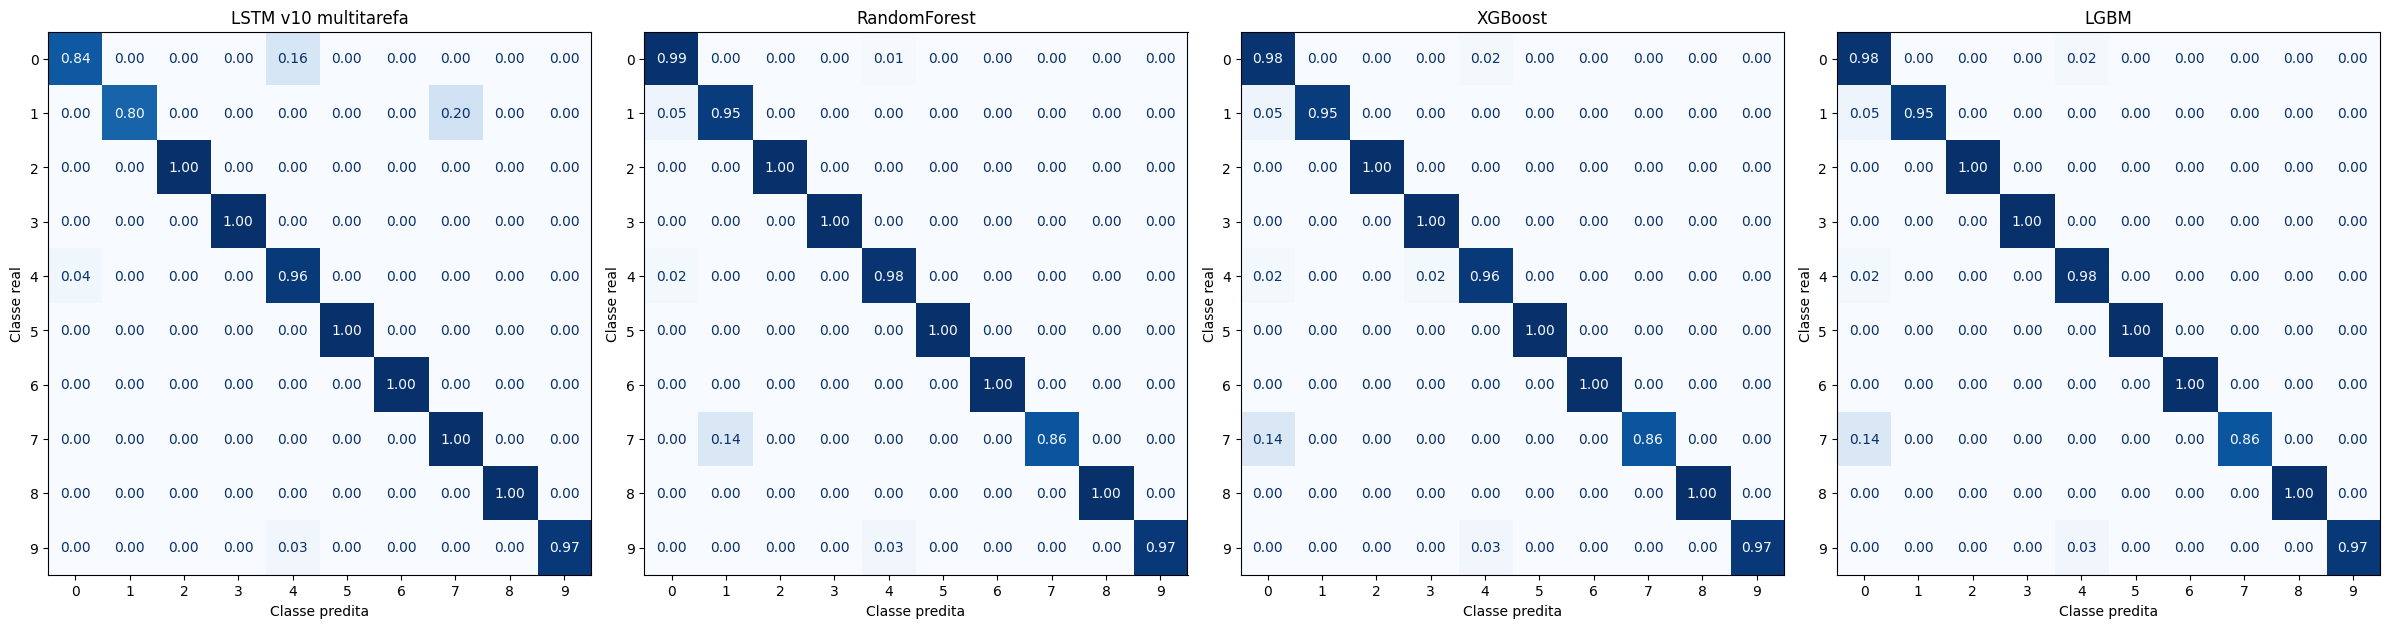

In [7]:
model_specs = [
    ("LSTM v10 multitarefa", multitask_test_pred),
    ("RandomForest", rf_test_pred),
]
if xgb_test_eval is not None:
    model_specs.append(("XGBoost", xgb_test_pred))
if lgbm_test_eval is not None:
    model_specs.append(("LGBM", lgbm_test_pred))

fig, axes = plt.subplots(1, len(model_specs), figsize=(6 * len(model_specs), 6))
if len(model_specs) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, model_specs):
    plot_confusion_matrix_for_predictions(
        test_arrays["y"],
        y_pred,
        bundle.class_labels,
        normalize="true",
        title=model_name,
        ax=ax,
    )

plt.tight_layout()
plt.show()

## Como interpretar este notebook

Esta comparacao final deve ser lida em tres niveis:

1. desempenho absoluto: a `LSTM v10` realmente melhorou ou nao?
2. desempenho relativo: ela encostou ou superou `RandomForest`, `XGBoost` e `LGBM`?
3. interpretacao metodologica: caso haja ganho, ele veio de um uso mais fiel do dataset, e nao apenas de mais parametros.

Mesmo que a `versao10` ainda nao vença a baseline, ela ja sera valiosa se mostrar que o caminho correto e explorar melhor a estrutura do `3W`, especialmente os rotulos por observacao e os sinais operacionais preservados nas instancias reais.